# Google Play store Data set 
- you find in on github : krishnaik06/playstore-Dataset

## Objective : Find Most Popular Apps Category -> find app with largest nmbr of installs , app the largest size etc

### 20 cols and 10841 rows


## Concepts 
- Data cleaning 
- EDA 
- Feature Engineerin

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv("googleplaystore.csv")

In [3]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
df.shape

(10841, 13)

In [3]:
df.info()

## Almost all col are str type

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
# Find Missing Values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

# Insight and Observation 

the Dataset has missing vales 

---

Now Catch every col and try to make it valueable 

---


# Data Cleaning

In [8]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# Lets Refine reviews col
# we know from above its n 'str' format 
# when convert it , it will throw an error as one col is non-numeric in this cols

df["Reviews"].astype(int)

# its saying one col has 3.0M that is non-numeric ... so fix this issue 

ValueError: invalid literal for int() with base 10: '3.0M'

In [4]:
# Lets Refine reviews col
# we know from above its n 'str' format 

# 1st check if all the values in "reviews" col are numeric or not 

df["Reviews"].str.isnumeric().sum()
# see it gave 10840 values .. but we have 10841 rows means one is non non numeric 
# in belows cell find 

np.int64(10840)

In [5]:
# find row that is non numeric
df[~df["Reviews"].str.isnumeric()]

# row 10472 is non numeric as it has value 3.0M
# now we will drop this col 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [6]:
# deketing the non-numeric row   ( as we are cleaning data so make copy of og df and make changes in that )

df_copy = df.copy()

# now drop the row of non-numeric reviews

df_copy.drop(df_copy.index[10472], inplace= True)

# now check if it got handle or not 

df_copy[~df_copy["Reviews"].str.isnumeric()]  # see the row deonet exist now

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [7]:
# Convert Revie into numeric now 

df_copy["Reviews"] = df_copy["Reviews"].astype("int32")

---

In [8]:
# Now size Col
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [9]:
# Size col 
df_copy["Size"].unique()

<ArrowStringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [10]:
# it has values like these

# 19M   -> 19000000
# 467k  -> 467000
# 8.7M  -> 8700000

# I wll make a function that handles these conversions

def convert_size(x):

    if "M" in x:
        return float(x.replace("M", "")) * 1000000

    elif "k" in x:
        return float(x.replace("k", "")) * 1000
    

# apply the convertion function    
df_copy["Size"] = df_copy["Size"].apply(convert_size)

In [ ]:
# now check 
df_copy["Size"].unique()
# see there is one nan value 

array([1.90e+07, 1.40e+07, 8.70e+06, 2.50e+07, 2.80e+06, 5.60e+06,
       2.90e+07, 3.30e+07, 3.10e+06, 2.80e+07, 1.20e+07, 2.00e+07,
       2.10e+07, 3.70e+07, 2.70e+06, 5.50e+06, 1.70e+07, 3.90e+07,
       3.10e+07, 4.20e+06, 7.00e+06, 2.30e+07, 6.00e+06, 6.10e+06,
       4.60e+06, 9.20e+06, 5.20e+06, 1.10e+07, 2.40e+07,      nan,
       9.40e+06, 1.50e+07, 1.00e+07, 1.20e+06, 2.60e+07, 8.00e+06,
       7.90e+06, 5.60e+07, 5.70e+07, 3.50e+07, 5.40e+07, 2.01e+05,
       3.60e+06, 5.70e+06, 8.60e+06, 2.40e+06, 2.70e+07, 2.50e+06,
       1.60e+07, 3.40e+06, 8.90e+06, 3.90e+06, 2.90e+06, 3.80e+07,
       3.20e+07, 5.40e+06, 1.80e+07, 1.10e+06, 2.20e+06, 4.50e+06,
       9.80e+06, 5.20e+07, 9.00e+06, 6.70e+06, 3.00e+07, 2.60e+06,
       7.10e+06, 3.70e+06, 2.20e+07, 7.40e+06, 6.40e+06, 3.20e+06,
       8.20e+06, 9.90e+06, 4.90e+06, 9.50e+06, 5.00e+06, 5.90e+06,
       1.30e+07, 7.30e+07, 6.80e+06, 3.50e+06, 4.00e+06, 2.30e+06,
       7.20e+06, 2.10e+06, 4.20e+07, 7.30e+06, 9.10e+06, 5.50e

In [11]:
# okay convert it 
df_copy["Size"] = df_copy["Size"].astype("float32")

# fill the nan Value
df_copy["Size"] = df_copy["Size"].fillna(df_copy["Size"].mean())

In [ ]:
df_copy["Size"].unique()

array([1.900000e+07, 1.400000e+07, 8.700000e+06, 2.500000e+07,
       2.800000e+06, 5.600000e+06, 2.900000e+07, 3.300000e+07,
       3.100000e+06, 2.800000e+07, 1.200000e+07, 2.000000e+07,
       2.100000e+07, 3.700000e+07, 2.700000e+06, 5.500000e+06,
       1.700000e+07, 3.900000e+07, 3.100000e+07, 4.200000e+06,
       7.000000e+06, 2.300000e+07, 6.000000e+06, 6.100000e+06,
       4.600000e+06, 9.200000e+06, 5.200000e+06, 1.100000e+07,
       2.400000e+07, 2.151653e+07, 9.400000e+06, 1.500000e+07,
       1.000000e+07, 1.200000e+06, 2.600000e+07, 8.000000e+06,
       7.900000e+06, 5.600000e+07, 5.700000e+07, 3.500000e+07,
       5.400000e+07, 2.010000e+05, 3.600000e+06, 5.700000e+06,
       8.600000e+06, 2.400000e+06, 2.700000e+07, 2.500000e+06,
       1.600000e+07, 3.400000e+06, 8.900000e+06, 3.900000e+06,
       2.900000e+06, 3.800000e+07, 3.200000e+07, 5.400000e+06,
       1.800000e+07, 1.100000e+06, 2.200000e+06, 4.500000e+06,
       9.800000e+06, 5.200000e+07, 9.000000e+06, 6.7000

----

In [29]:
# Now Insall and Price Cols 
# Observe they both have special characters like + $ etc

df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [12]:
df_copy["Installs"].unique()

<ArrowStringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [31]:
df_copy["Price"].unique()

<ArrowStringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', 

In [13]:
# now in Both col replace these special charaters with blank i.e ""

chars_to_remove = ["+", "$" , ","]
cols_to_clean = ["Price" , "Installs"]

for items in chars_to_remove:
    for col in cols_to_clean:
        df_copy[col] = df_copy[col].str.replace(items, "")

In [14]:
# now check 
df_copy["Installs"].unique()

# Observe the + sign has been removed

<ArrowStringArray>
[     '10000',     '500000',    '5000000',   '50000000',     '100000',
      '50000',    '1000000',   '10000000',       '5000',  '100000000',
 '1000000000',       '1000',  '500000000',         '50',        '100',
        '500',         '10',          '1',          '5',          '0']
Length: 20, dtype: str

In [35]:
df_copy["Price"].unique()

<ArrowStringArray>
[     '0',   '4.99',   '3.99',   '6.99',   '1.49',   '2.99',   '7.99',
   '5.99',   '3.49',   '1.99',   '9.99',   '7.49',   '0.99',   '9.00',
   '5.49',  '10.00',  '24.99',  '11.99',  '79.99',  '16.99',  '14.99',
   '1.00',  '29.99',  '12.99',   '2.49',  '10.99',   '1.50',  '19.99',
  '15.99',  '33.99',  '74.99',  '39.99',   '3.95',   '4.49',   '1.70',
   '8.99',   '2.00',   '3.88',  '25.99', '399.99',  '17.99', '400.00',
   '3.02',   '1.76',   '4.84',   '4.77',   '1.61',   '2.50',   '1.59',
   '6.49',   '1.29',   '5.00',  '13.99', '299.99', '379.99',  '37.99',
  '18.99', '389.99',  '19.90',   '8.49',   '1.75',  '14.00',   '4.85',
  '46.99', '109.99', '154.99',   '3.08',   '2.59',   '4.80',   '1.96',
  '19.40',   '3.90',   '4.59',  '15.46',   '3.04',   '4.29',   '2.60',
   '3.28',   '4.60',  '28.99',   '2.95',   '2.90',   '1.97', '200.00',
  '89.99',   '2.56',  '30.99',   '3.61', '394.99',   '1.26',   '1.20',
   '1.04']
Length: 92, dtype: str

In [15]:
# Now convert the type 
df_copy["Price"] = df_copy["Price"].astype(float)
df_copy["Installs"] = df_copy["Installs"].astype(int)

In [16]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            10840 non-null  float32
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float32(1), float64(2), int32(1), int64(1), str(8)
memory usage: 2.0 MB


----

In [ ]:
# now last updated 
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [17]:
# observe last Updated Cols ... Dates are wriiten cleanly 
# so convert it to date time using pd.to_datetime()

df_copy["Last Updated"] = pd.to_datetime(df_copy["Last Updated"])
df_copy['Last Updated'] # see it has beome numeric type dates .. before it was january - 35- 2020 now its 2020-1-25

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10840, dtype: datetime64[us]

In [18]:
# now separate Day month and year .. as now col type is datetime so we can use " dt "

df_copy["Day"] = df_copy["Last Updated"].dt.day
df_copy["Month"] = df_copy["Last Updated"].dt.month
df_copy["Year"] = df_copy["Last Updated"].dt.year

In [45]:
# now check 
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  str           
 1   Category        10840 non-null  str           
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int32         
 4   Size            10840 non-null  float32       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  str           
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  str           
 9   Genres          10840 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10832 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year            10

In [19]:
df_copy.to_csv("cleaned_google_data.csv")

----
----

# EDA

In [20]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000.0,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [ ]:
# See if there is any duplicates   in App col 

df_copy[df_copy.duplicated("App")].shape

# observation out of 10840 values 1181 are duplicates 

(1181, 16)

# Observation 

the Data set has duplicates

In [24]:
df_copy = df_copy.drop_duplicates(subset=["App"], keep= "first")
# Remove duplicate app names
# subset=["App"] -> check duplicates only using App column
# keep="first" -> keep first occurrence and remove later duplicates

In [ ]:
df_copy.shape
# see col drops 

(9659, 16)

# Explore Data

In [ ]:
# see how many numeric and categorical Features you have 

# loop through all columns
# if datatype is NOT string -> store in numeric_features   
# if datatype IS string -> store in categorical_features
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'str']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'str']

# print Cols 

print(" We have  {} numeric features : {} ".format(len(numeric_features), numeric_features))
print("we have {} categorical features : {} ".format(len(categorical_features), categorical_features))

 We have  9 numeric features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year'] 
we have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver'] 


# Find Proportion 

In [32]:
## proportion of count on categorical cols 

for col in categorical_features:
    print(df_copy[col].value_counts(normalize=True)*100) # when normalize = true then instead of numerber we will get in inform of percentage 
    print("---------------------------------")


App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
---------------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY   

In [ ]:
# proportion of Numeric COls 

for col in numeric_features:
    print( df_copy[col].value_counts(normalize=True)* 100 )
    print(" ----------------  ")

Rating
4.3    10.944363
4.4    10.919961
4.5    10.346510
4.2     9.882870
4.6     8.333333
4.1     7.576867
4.0     6.259151
4.7     5.392875
3.9     4.380185
3.8     3.489507
5.0     3.306491
3.7     2.733041
4.8     2.696437
3.6     2.037579
3.5     1.903367
3.4     1.537335
3.3     1.220107
4.9     1.037091
3.0     0.988287
3.1     0.841874
3.2     0.768668
2.9     0.549048
2.8     0.488043
2.6     0.292826
2.7     0.280625
2.5     0.244021
2.3     0.244021
2.4     0.231820
1.0     0.195217
2.2     0.170815
2.0     0.146413
1.9     0.134212
1.7     0.097609
1.8     0.097609
2.1     0.097609
1.6     0.048804
1.4     0.036603
1.5     0.036603
1.2     0.012201
Name: proportion, dtype: float64
 ----------------  
Reviews
0         6.139352
1         2.816027
2         2.205197
3         1.760017
4         1.418366
            ...   
885       0.010353
88486     0.010353
603       0.010353
1195      0.010353
398307    0.010353
Name: proportion, Length: 5330, dtype: float64
 ------------

# Using plots

/tmp/ipykernel_3709/3871846234.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x= df_copy[numeric_features[i]], shade = True, color= 'r')
/tmp/ipykernel_3709/3871846234.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x= df_copy[numeric_features[i]], shade = True, color= 'r')
/tmp/ipykernel_3709/3871846234.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x= df_copy[numeric_features[i]], shade = True, color= 'r')
/tmp/ipykernel_3709/3871846234.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kde

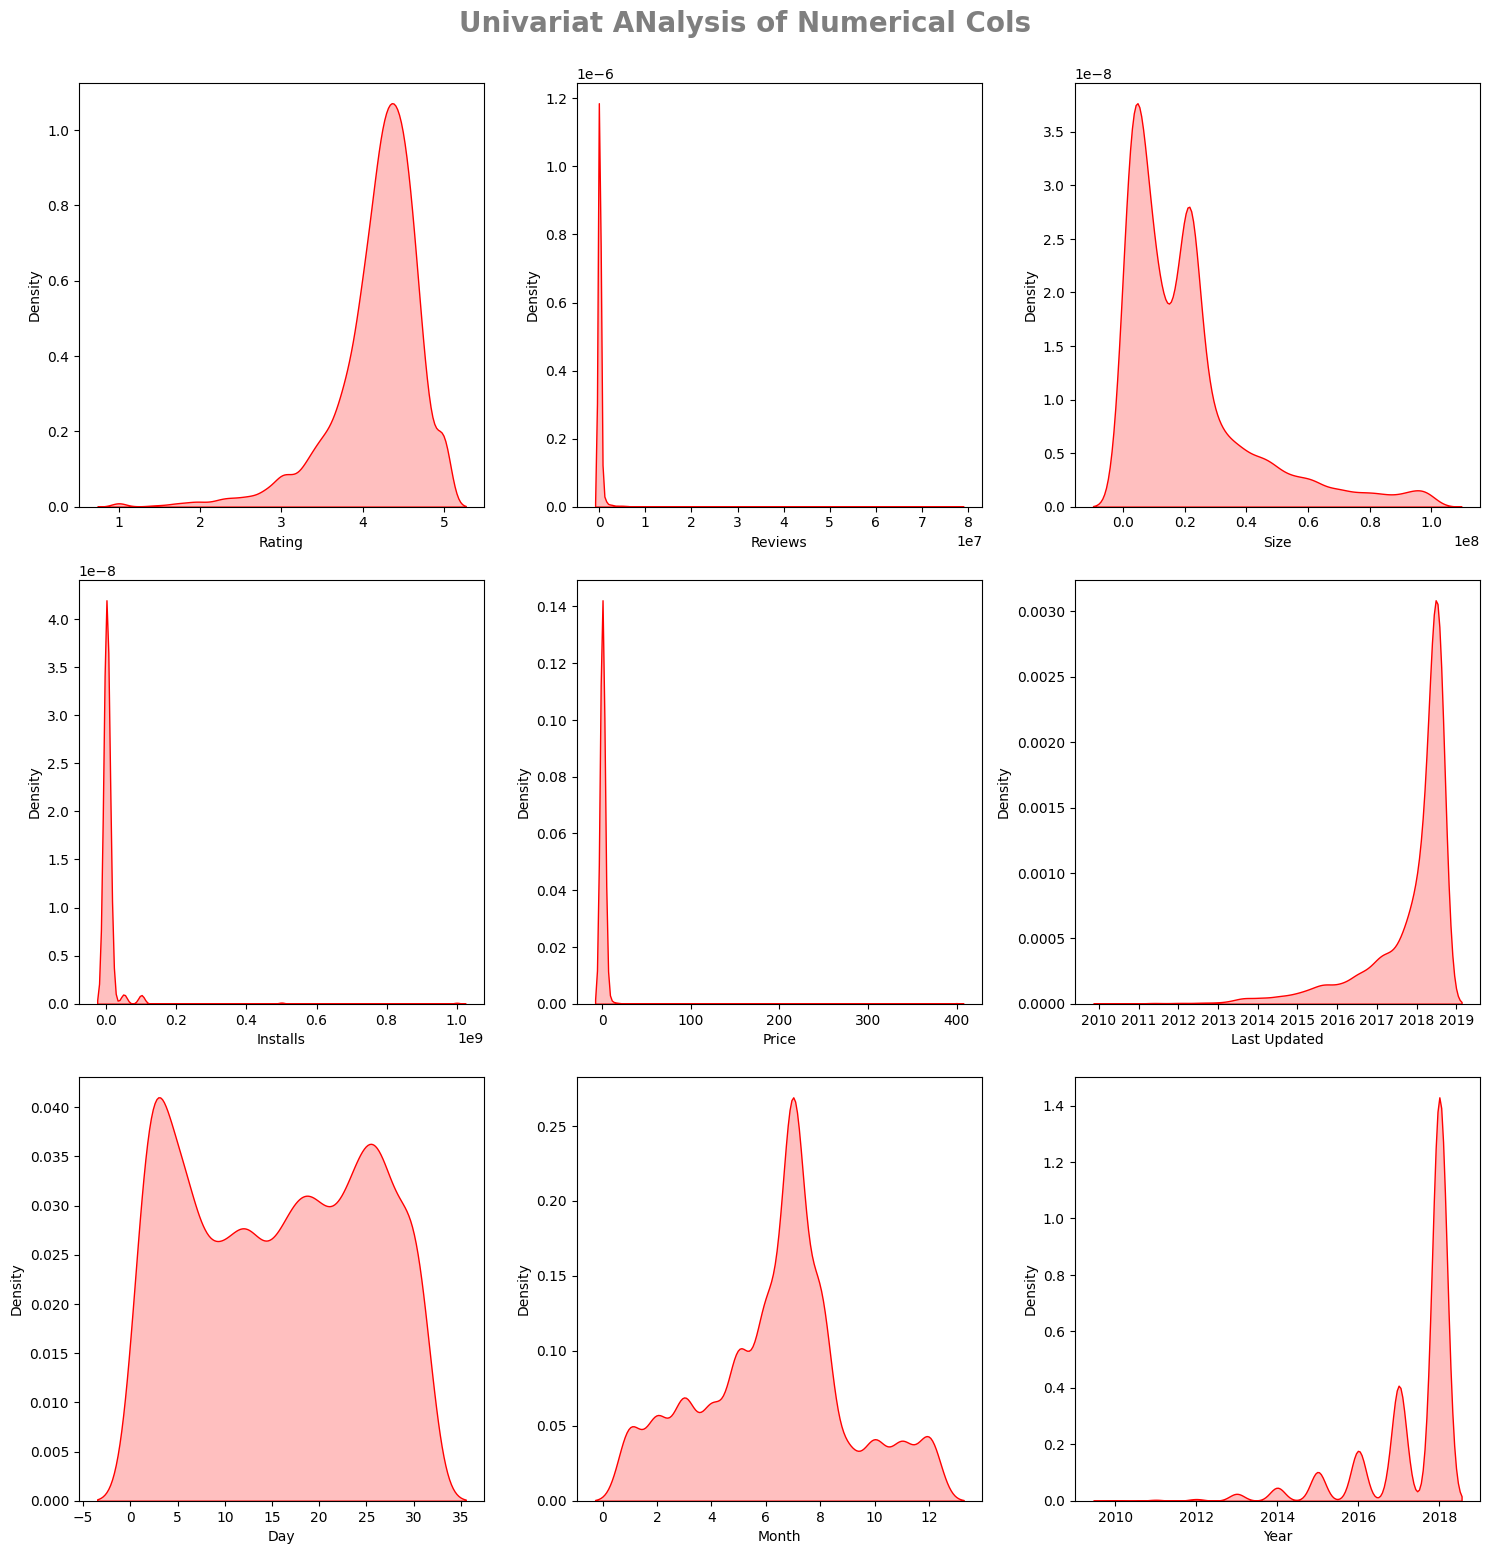

In [ ]:
# for numeric Features 

plt.figure(figsize=(15,25))
plt.suptitle("Univariat ANalysis of Numerical Cols", fontsize = 20, fontweight = 'bold' , alpha = 0.5 , y =1)

for i in range(0, len(numeric_features)):
    # create subplot grid
    # 5 rows, 3 columns
    # i+1 decides current plot position

    # example:
    # i=0 -> subplot(5,3,1)
    # i=1 -> subplot(5,3,2)
    # i=2 -> subplot(5,3,3)
    plt.subplot(5,3, i+1)
    sns.kdeplot(x= df_copy[numeric_features[i]], shade = True, color= 'r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

# Observation 

- 1. Rating and Year is left skwed 
- 2. Reviews, Size, Installs and Price is Right skwed 

/tmp/ipykernel_3709/2593060965.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]], palette="Set2")
/tmp/ipykernel_3709/2593060965.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]], palette="Set2")


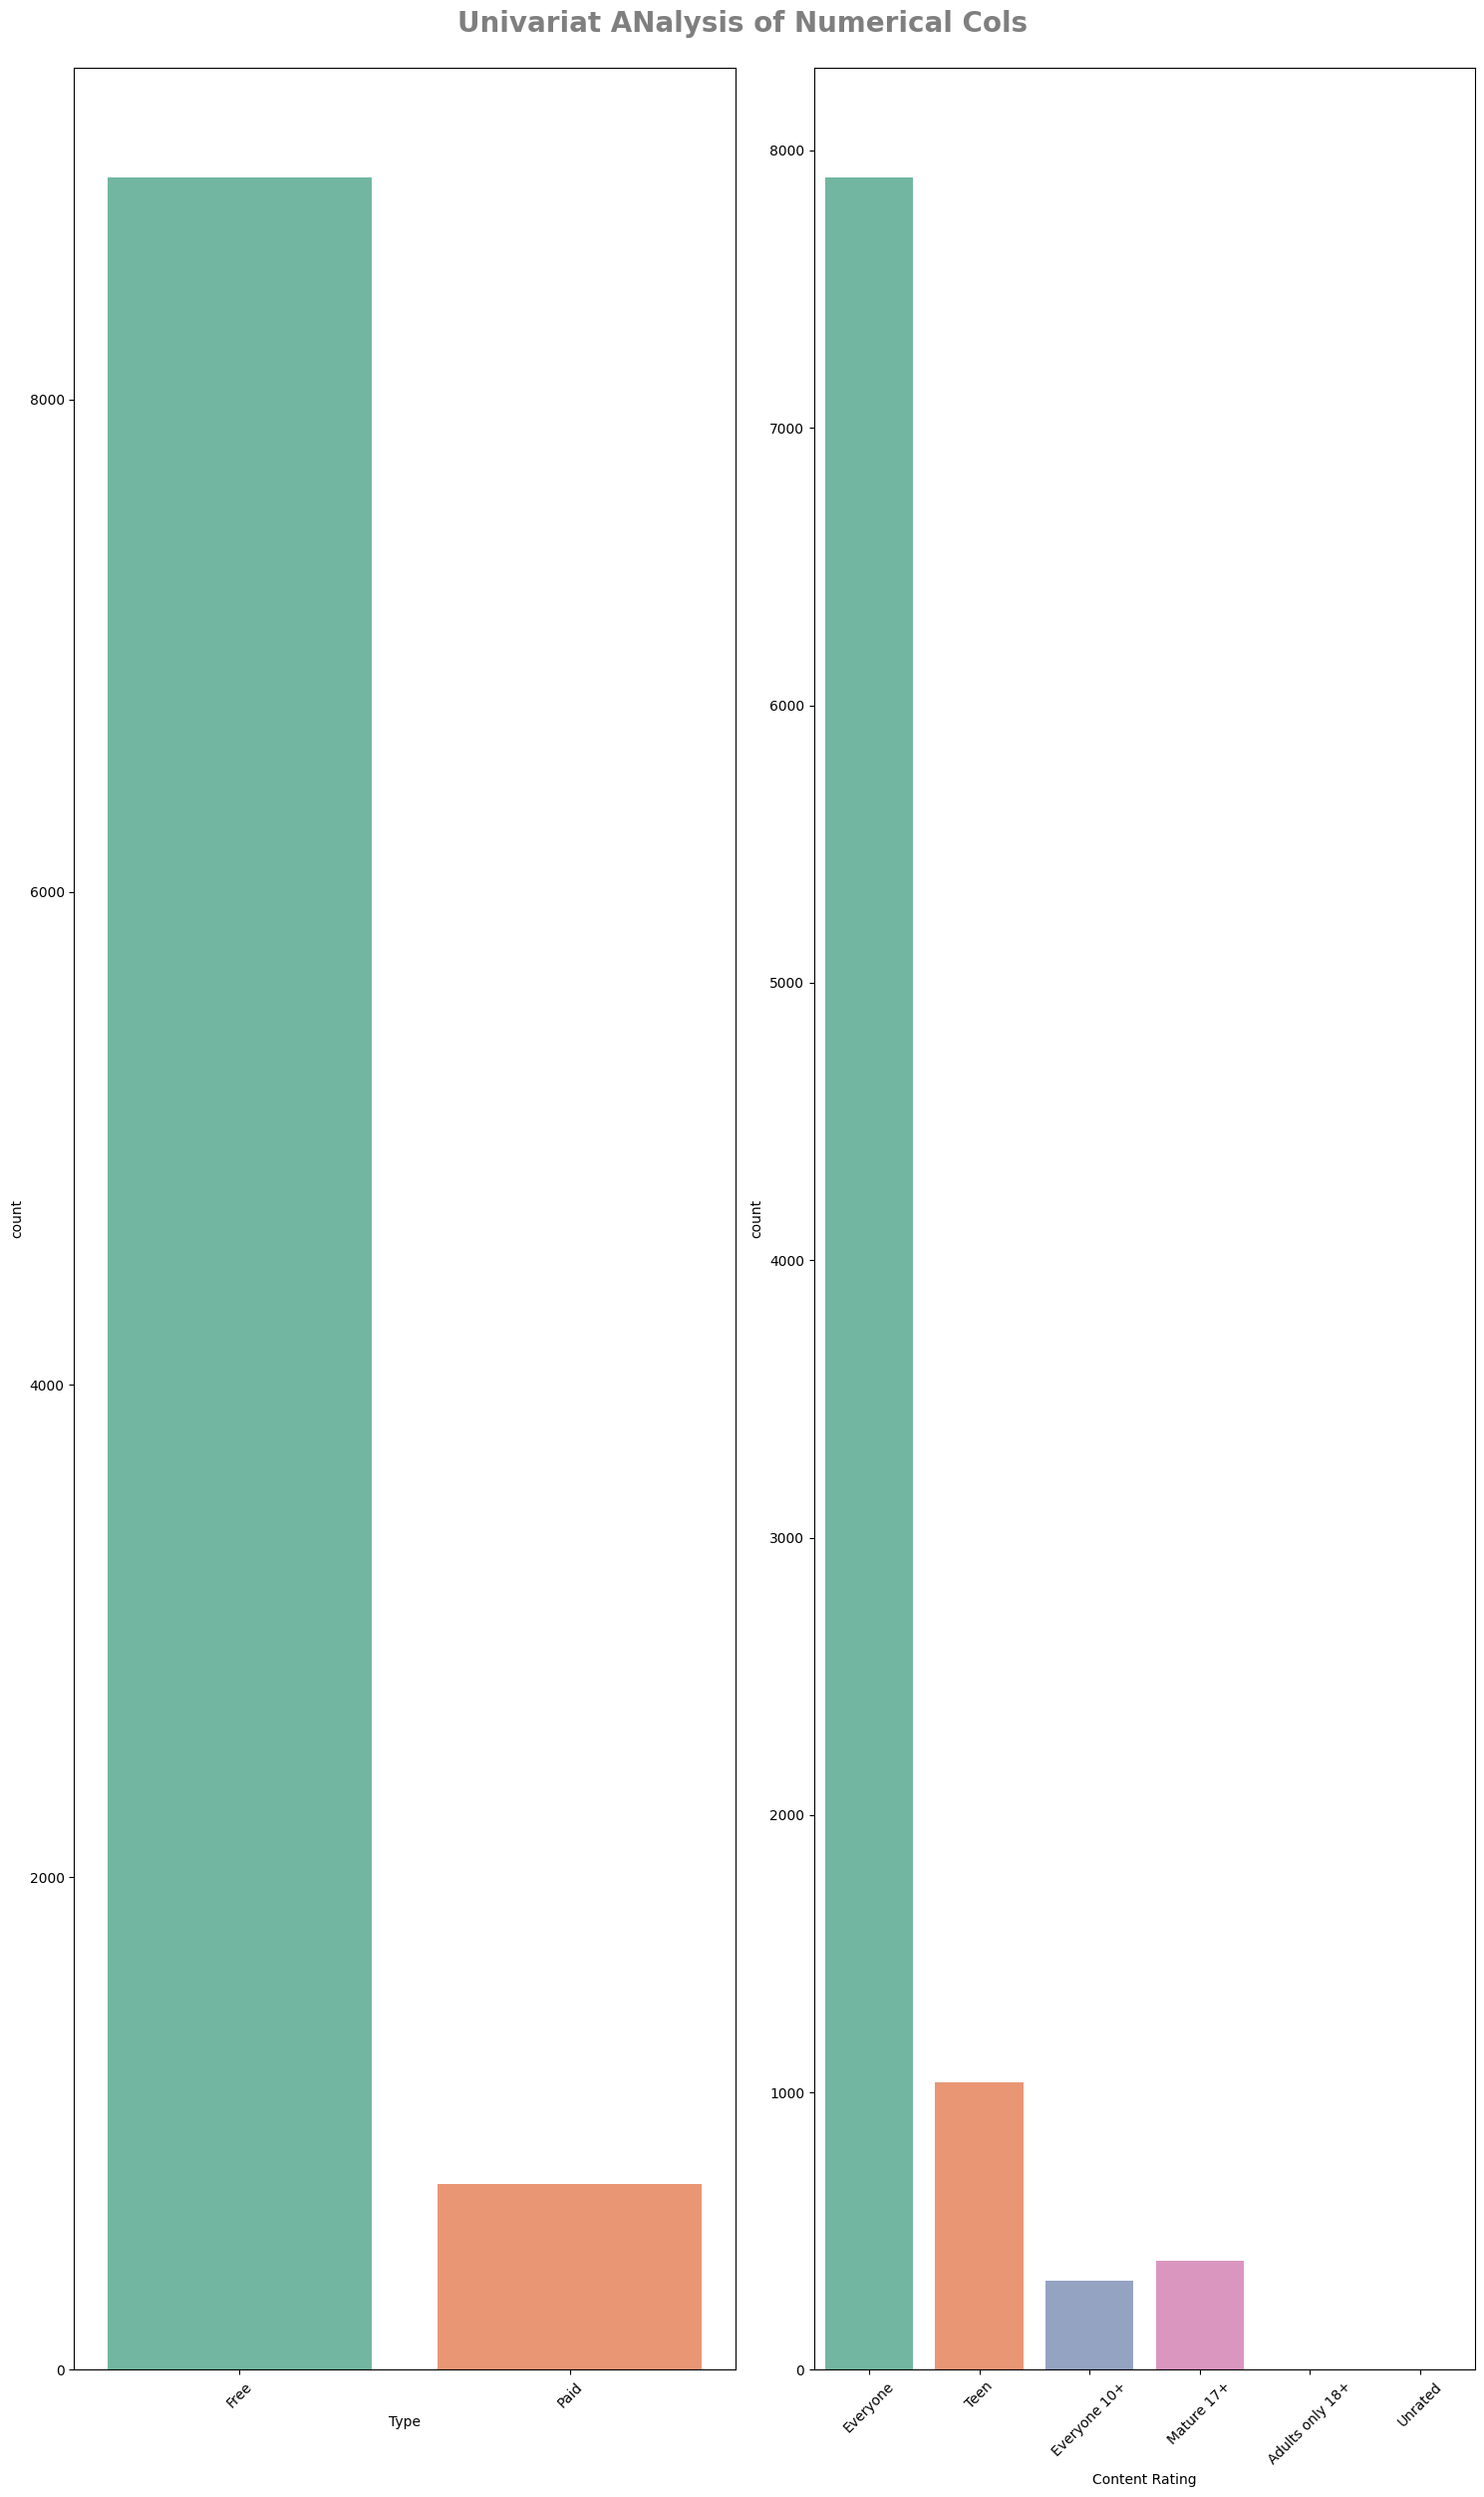

In [ ]:
# for Categorical  Features 
# for categorical Use Count plot 

plt.figure(figsize=(15,25))
plt.suptitle("Univariat ANalysis of Numerical Cols", fontsize = 20, fontweight = 'bold' , alpha = 0.5 , y =1)

category = ['Type', 'Content Rating']
# Type → Free, Paid
# Content Rating → Everyone, Teen, Mature…
for i in range(len(category)):
    plt.subplot(1, 2, i+1)
    
    sns.countplot(x=df_copy[category[i]], palette="Set2")
    
    plt.xlabel(category[i])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# observation 
- 1. Free tier has Huge count as comapred to paid
- 2. Everyone has more count 

In [48]:
# which is most popular App category 
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


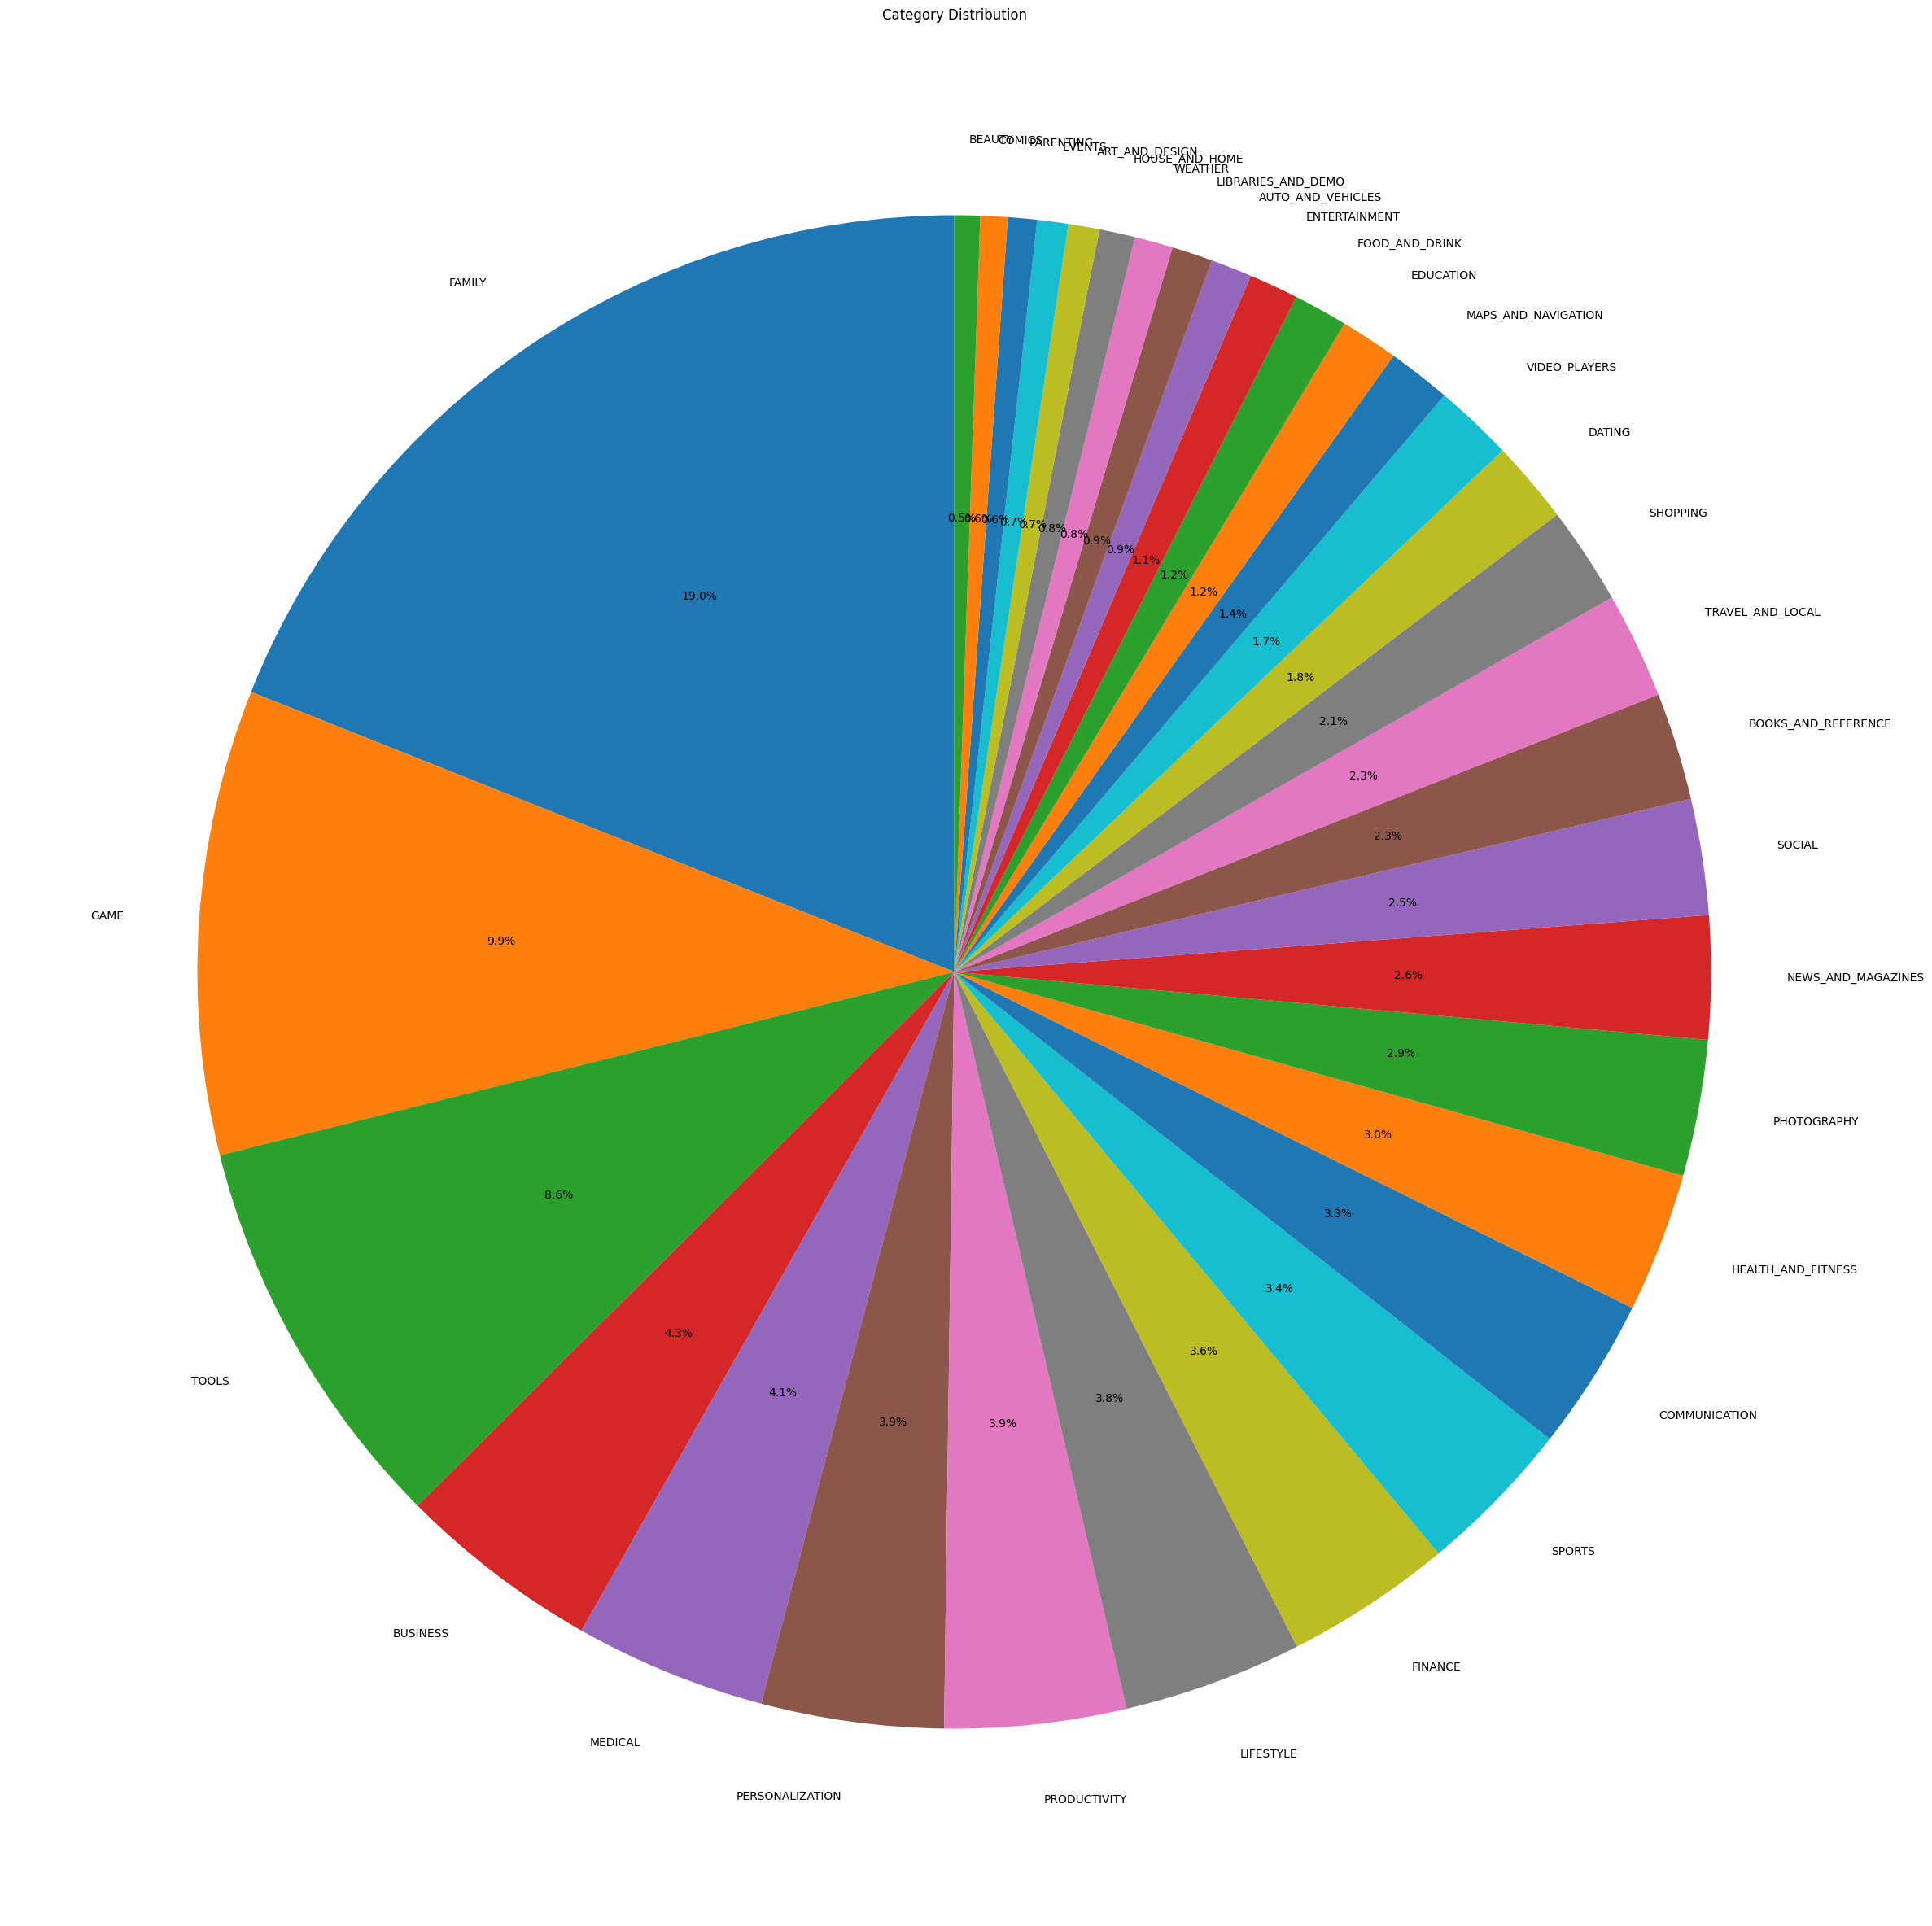

In [ ]:
# do this based on Catgory col 

plt.figure(figsize=(30,40))

df_copy["Category"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")  # removes ugly 'Category' label
plt.title("Category Distribution")
plt.show()

-1. There are more kinds of apps in playstore under category of family, games and tools

-2. beauty , cosmatics and wethers kinds of apps are less

In [58]:
# Top 10 App Categories 

# Step 1: Count how many times each category appears
# This returns a Series where:
# index = category name
# value = frequency count
category = df_copy["Category"].value_counts()

# Step 2: Convert Series into DataFrame
# Now we get a proper table instead of a Series
category = pd.DataFrame(category)

# Step 3: Rename the column from "Category" (default name) to "Count"
# This makes the table more meaningful and readable
category.rename(columns={"Category": "Count"}, inplace=True)

In [59]:
category

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


/tmp/ipykernel_3709/2275300497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


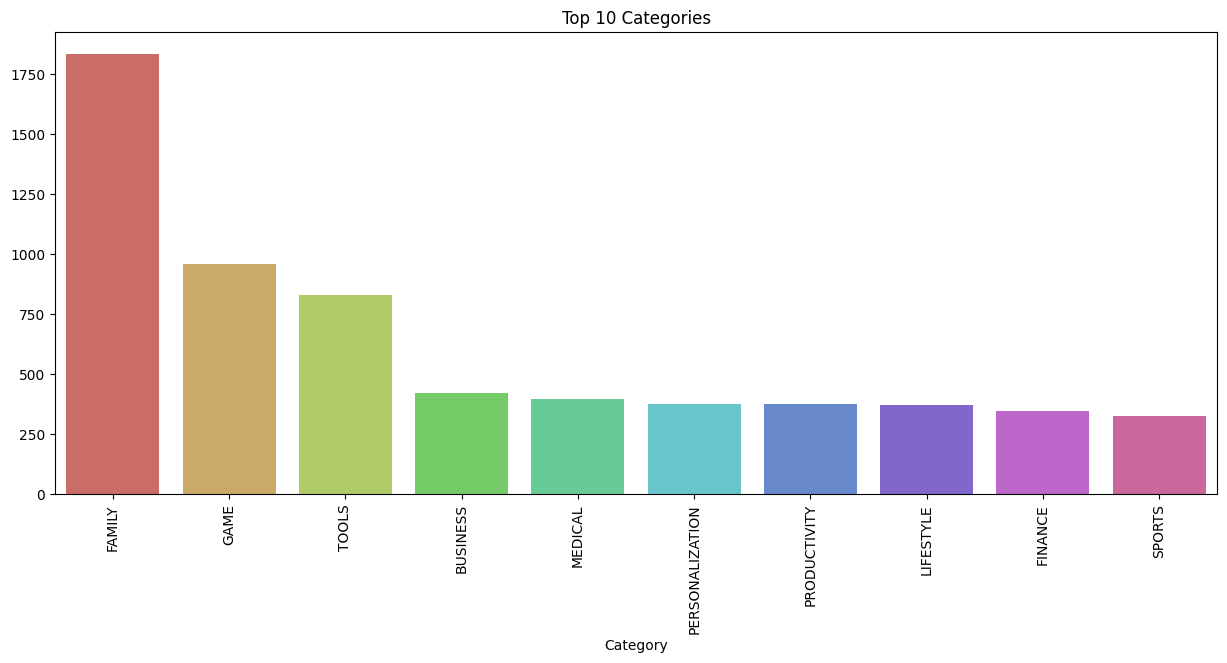

In [ ]:
# creae a bar chart

category = df_copy["Category"].value_counts().head(10)
plt.figure(figsize=(15,6))

# category.index	category names
# category.values	counts

sns.barplot(
    x=category.index,
    y=category.values,
    palette="hls"
)

plt.title("Top 10 Categories")
plt.xticks(rotation=90)
plt.show()

---
---


In [ ]:
# which category has largest insallation
# what are top 5 apps in each category 
# how many apps in google play store that got 5 rating 

In [67]:
df_copy["Installs"].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [69]:
## which category has largest insallation
category_installs = df_copy.groupby("Category")["Installs"].sum().sort_values(ascending=False)

category_installs

Category
GAME                   13878924415
COMMUNICATION          11038276251
TOOLS                   8001771915
PRODUCTIVITY            5793091369
SOCIAL                  5487867902
PHOTOGRAPHY             4649147655
FAMILY                  4427941505
VIDEO_PLAYERS           3926902720
TRAVEL_AND_LOCAL        2894887146
NEWS_AND_MAGAZINES      2369217760
ENTERTAINMENT           2113660000
BOOKS_AND_REFERENCE     1665969576
PERSONALIZATION         1532494782
SHOPPING                1400348785
HEALTH_AND_FITNESS      1144022512
SPORTS                  1096474498
BUSINESS                 697164865
LIFESTYLE                503823539
MAPS_AND_NAVIGATION      503281890
FINANCE                  455348734
WEATHER                  361100520
EDUCATION                352952000
FOOD_AND_DRINK           211798751
DATING                   140926107
ART_AND_DESIGN           114338100
HOUSE_AND_HOME            97212461
AUTO_AND_VEHICLES         53130211
LIBRARIES_AND_DEMO        52995910
COMICS     

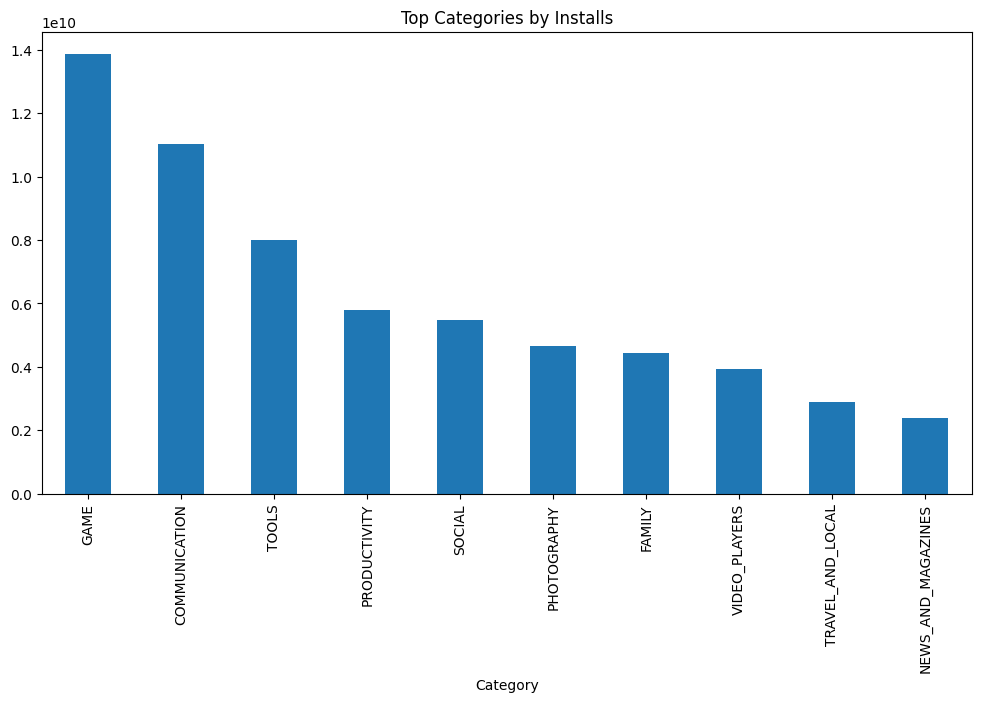

In [70]:
category_installs.head(10).plot(kind="bar", figsize=(12,6))
plt.title("Top Categories by Installs")
plt.show()

---

In [ ]:
# what are top 5 apps in each category 


# Step 1: Group the dataset by "Category"
# This splits the data into separate groups for each category (e.g., GAME, FAMILY, TOOLS, etc.)
df_copy.groupby("Category")

# Step 2: Apply a function to each group
# For each category group:
#   - sort apps by "Installs" in descending order (highest installs first)
#   - take only the top 5 apps from each category
top_apps = df_copy.groupby("Category").apply(
    lambda x: x.sort_values("Installs", ascending=False).head(5)
)

# Step 3: Keep only relevant columns
# After getting top 5 apps per category, select only:
#   - App name
#   - Number of Installs
top_apps = top_apps[["App", "Installs"]]

top_apps

App  \
Category                                                                 
ART_AND_DESIGN 3                                 Sketch - Draw & Paint   
               12                       Tattoo Name On My Photo Editor   
               19                                         ibis Paint X   
               45    Canva: Poster, banner, card maker & graphic de...   
               42                           Textgram - write on photos   
...                                                                ...   
WEATHER        3626  The Weather Channel: Rain Forecast & Storm Alerts   
               3628  AccuWeather: Daily Forecast & Live Weather Rep...   
               3649   GO Weather - Widget, Theme, Wallpaper, Efficient   
               4725                 Weather & Clock Widget for Android   
               3636                   Weather –Simple weather forecast   

                     Installs  
Category                       
ART_AND_DESIGN 3     50000000  
               12    10000000  
               19    10000000  
               45    10000000  
               42    10000000  
...                       ...  
WEATHER        3626  50000000  
               3628  50000000  
               3649  50000000  
               4725  50000000  
               3636  10000000  

[165 rows x 2 columns]

---


In [75]:
# how many apps in google play store that got 5 rating 

df_copy[df_copy["Rating"] == 5.0].shape[0]

271